<a href="https://colab.research.google.com/github/49262532M/Procesos-Estoc-sticos/blob/main/Simulaciones_PAS_Silvia_Raso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En primer lugar añado la librería Numpy, que utilizaré para generar números aleatorios, imprescindible para lo que queremos; crear matrices o calcular las sumas acumuladas; y añado Matplotlib para visualizar las trayectorias del PAS, es decir, para dibujar las gráficas correspondientes.

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
def simular_PAS(p, n, reps=1):
    #Input:
      #p:Probabilidad de tomar el valor 1 en cada paso. Es un valor entre 0 y 1.
      #n:Número de pasos en cada trayectoria
      #reps:Número de trayectorias a simular

    #Output:
      #Devuelve una matriz de shape (reps,n) que contiene las posiciones del paseo aleatorio en cada paso, es decir, las sumas acumuladas.
      #En esta matriz las filas son cada una de las trayectorias y las columnas son un paso en el tiempo.

    #Utilizo la función np.random.reps para crear una matriz de tamaño (reps,n) con números aleatoriso entre 0 y 1
    #Shape:(reps, n)
    matriz=np.random.rand(reps,n)

    #Ahora utilizo la función del numpy, "np.where" para convertir a pasos la matriz construida, de manera que si el número aleatorio
    #es <p, entonces será 1; y de lo contrario (>p) será -1.
    pasos = np.where(matriz < p,1,-1)

    #Calculo la suma acumulada por filas, es decir por cada trayectoria (axis=1), para ver como evoluciona cada una con el tiempo.
    #Para ello utilizo la función np.cumsum de la librería numpy.
    output = np.cumsum(pasos, axis=1)

    return output  #Shape: (reps, n)

**1. Visualización 1: Trayectorias del PAS sin media ni desviación típica teóricas para los valores de p: 0.5, 0.6 y 0.4.**

In [17]:
def graficas_pas_1(p, n=500, reps=5):
  #p:probabilidad de subir
  #n:número de pasos (por defecto pongo siempre 500)
  #reps:número de trayectorias (viendo las diapositivas, suelen ser 5, por lo que por defecto pongo 5)

  #Llamo a la función creada arriba en la variable trayectorias que tendrá shape (reps,n)
  trayectorias = simular_PAS(p, n, reps)

  #Esto no es necesario para representar las gráficas, pero lo hago lo más similares a las diapositivas de clase, por lo que,
  #añado en primer lugar el origen X_0=0 para que el origen empiece en 0, de la otra manera la gráfica empieza en X_1.
  #Luego pongo que el eje temporal vaya desde 0 hasta n, es decir, modifico el eje temporal para el cambio añadiendo el X_0.
  trayectorias = np.hstack((np.zeros((reps, 1)), trayectorias))
  t = np.arange(0, n + 1)

  #Creo un bucle que recorre cada trayectoria y dibuja una línea por cada una.
  for i in range(reps):
      plt.plot(t, trayectorias[i])

  #Añado etiquetas en los ejes, siendo el eje X el tiempo y el eje Y la posición del paseo. Así como una cuadrícula con la función "plt.grid" y muestro la gráfica con "plt.show."
  plt.xlabel('t')
  plt.ylabel(r'$X_t$')
  plt.grid(True, alpha=0.3)
  plt.title(f'Trayectorias del PAS con p = {p}')
  plt.show()

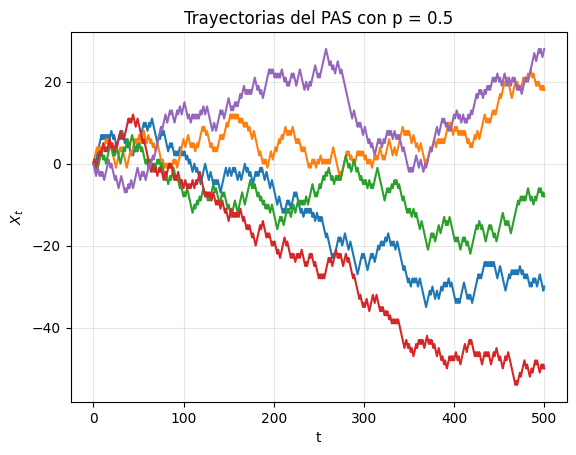

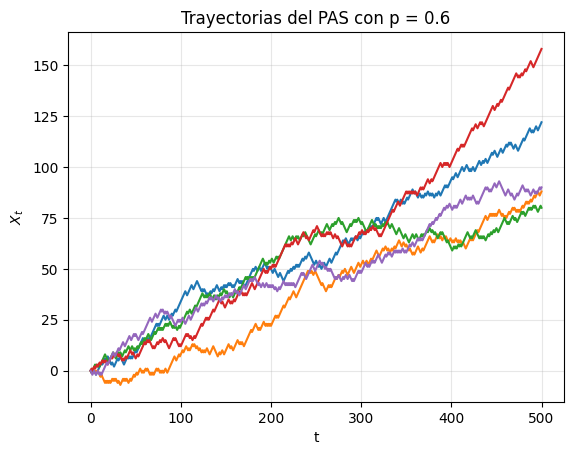

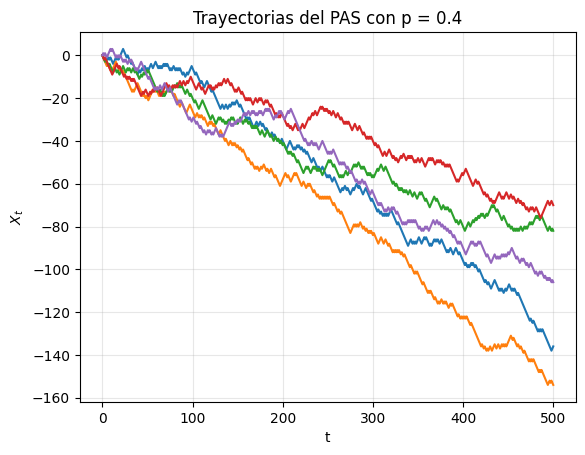

In [18]:
#Añado el "np.random.seed" para fijar los números aleatorios y cuando pasemos una matriz siempre salgan los mismos resultados.
np.random.seed(1)
graficas_pas_1(0.5)
graficas_pas_1(0.6)
graficas_pas_1(0.4)


**2. Visualización 2: Trayectorias del PAS con media y desviación típica teóricas para los valores de p: 0.5, 0.75 y 0.95.**

Busco entre las funciones de la librería matplotlib, y encuentro la función "plt.fill_between" que nos rellena el área entre dos curvas, lo que necesitaré para rellenar las bandas entre +/- sigma.

Por otro lado, en esta segunda función utilizo la media y desviación típica teóricas por lo que basándome en las fórmulas dadas en la teoría, vamos a ver cómo las usaremos:
- Para la media sé que su fórmula es $$E[X_n] = (2p-1)n$$ y como quiero que se vean todos los tiempos a la vez, sustituyo la t por la n, obteniendo así la siguiente fórmula: $$E[S_t]=(2p-1)t$$

- Para la desviación típica utilizo la fórmula de los apuntes, y al igual que en la media, como queremos que representen todos los tiempos en la gráfica, multiplicaremos la fórmula obtenida por la variable t $$\sigma_t = \sqrt{4p(1-p)t}$$






In [19]:
def graficas_pas_2(p, n=500, reps=20):
  #Copio lo de la función graficas_pas_1 para añadir el término 0 a las gráficas y representar cada una de las trayectorias, ya que se
  #hace de la misma manera, pero en este caso las diapositivas tienen más reps, por lo que pongo 20 en vez de 5.
  trayectorias = simular_PAS(p, n, reps)
  trayectorias = np.hstack((np.zeros((reps, 1)), trayectorias))
  t = np.arange(0, n + 1)
  for i in range(reps):
        plt.plot(t, trayectorias[i],alpha=0.6)

  #Calculo la media teórica del paseo en cada instante t con la fórmula obtenida arriba. Para representarla utilizo el "plt.plot"
  #utilizando una línea negra discontinua para representarla, tal y como sale en las diapositivas.
  media = (2*p - 1) * t
  plt.plot(t, media, 'k--', label='Media teórica')

  #Calculo la desviación típica con la fórmula de arriba y represento las bandas ±1σ y ±2σ, que crean una banda [media-σ, media+σ] y
  #[media-2σ, media+2σ] respectivamente, donde la segunda contendrá la mayor parte de las trayectorias, y para diferenciarlas
  #represento una más clarita que la otra con el elemento "alpha".
  sigma = np.sqrt(4 * p * (1 - p) * t)
  plt.fill_between(t,media - sigma,media + sigma,color='grey',alpha=0.3,label='±1σ')
  plt.fill_between(t,media - 2*sigma,media + 2*sigma,color='grey',alpha=0.15,label='±2σ')

  plt.xlabel('t')
  plt.ylabel(r'$X_t$')
  plt.grid(True, alpha=0.3)
  plt.title(f'{reps} trayectorias de un PAS con p={p}')
  plt.legend()
  plt.show()

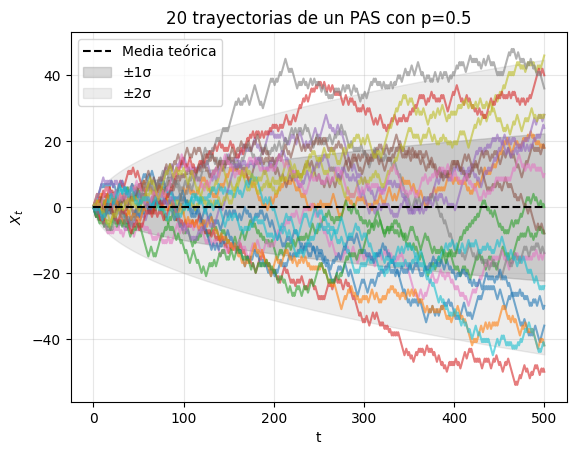

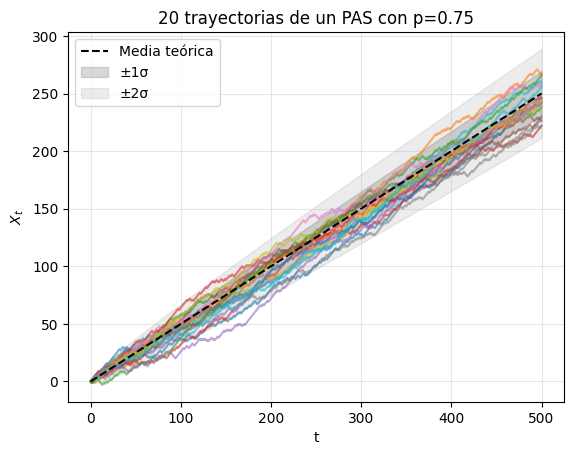

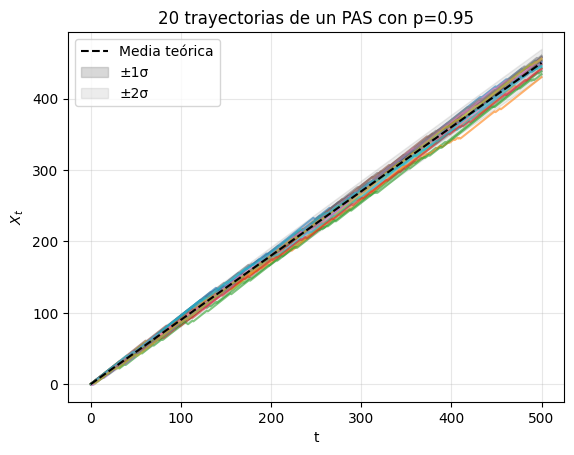

In [20]:
np.random.seed(1)
graficas_pas_2(p=0.5)
graficas_pas_2(p=0.75)
graficas_pas_2(p=0.95)


**3. Visualización 3: Visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica).**

In [21]:
def graficas_pas_3(p=0.5, n=500, max_reps=1000):
    #Primero simulo 1000 trayectorias, para que el resultado sea lo más exacto posible, e incluyo lo de la primera función.
    trayectorias = simular_PAS(p, n, max_reps) #tendrá shape (1000, n+1)
    trayectorias = np.hstack((np.zeros((max_reps, 1)), trayectorias))
    t = np.arange(0, n + 1)

    #Incluyo la fórmula obtenida en el apartado 2 para calcular la media teórica.
    media_teorica = (2*p - 1) * t
    plt.plot(t, media_teorica, color='red', label='Media teórica')

    #Promedio los 5 números de trayectorias dados en la gráfica de la diapositiva y calculo con ellas la media empírica
    lista = [5, 100, 200, 500, 1000]
    for r in lista:
        #Cojo las primeras r trayectorias y hago la media columna a columna, es decir hago media de todas las trayectorias de un tiempo
        #por lo que represento será la media de las r trayectorias en cada instante.
        media_empirica = np.mean(trayectorias[:r], axis=0)
        plt.plot(t, media_empirica, label=str(r))

    plt.xlabel('t')
    plt.ylabel(r'$X_t$')
    plt.grid(True, alpha=0.3)
    plt.title(f'Convergencia de la media empírica hacia la media teórica (p={p})')
    plt.legend()
    plt.show()

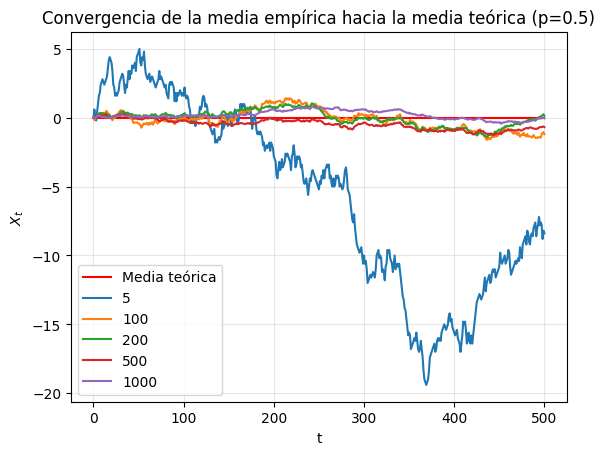

In [22]:
np.random.seed(1)
graficas_pas_3(p=0.5, n=500, max_reps=1000)

Como vemos, con pocas trayectorias la media empírica está más lejos de la teórica, pero conforme va aumentando el número de trayectorias se acerca más a la media teórica.